# Project: Modeling Neural Stability and Seizure Dynamics via the Wilson-Cowan Model

## I. Project Overview
This project utilizes **Dynamical Systems Theory** to simulate the interactions between excitatory and inhibitory neural populations. By mathematically modeling the "Edge of Chaos," we investigate how subtle changes in synaptic inhibition can drive a neural network from a healthy, stable state into the pathological oscillations characteristic of an epileptic seizure.

## II. Research Goals
1.  **Simulate Neural Dynamics:** Implement the Wilson-Cowan coupled differential equations to model mean firing rates of E-I populations.
2.  **Analyze Stability Regimes:** Demonstrate the transition from a **Stable Fixed Point** (Healthy State) to a **Limit Cycle Attractor** (Seizure State) by perturbing the inhibitory synaptic weight ($w_{EI}$).
3.  **Map Criticality:** Construct a Bifurcation Diagram to identify the precise mathematical threshold (Hopf Bifurcation) where stability is lost.

## III. Computational Techniques
* **Numerical Integration:** Solving coupled non-linear ODEs using the Runge-Kutta method (`scipy.integrate.solve_ivp`).
* **Phase Plane Analysis:** Visualizing the system's geometric structure and vector fields to identify topological attractors.
* **Parameter Sweeping:** Systematically varying synaptic weights to map the global dynamic range of the network.

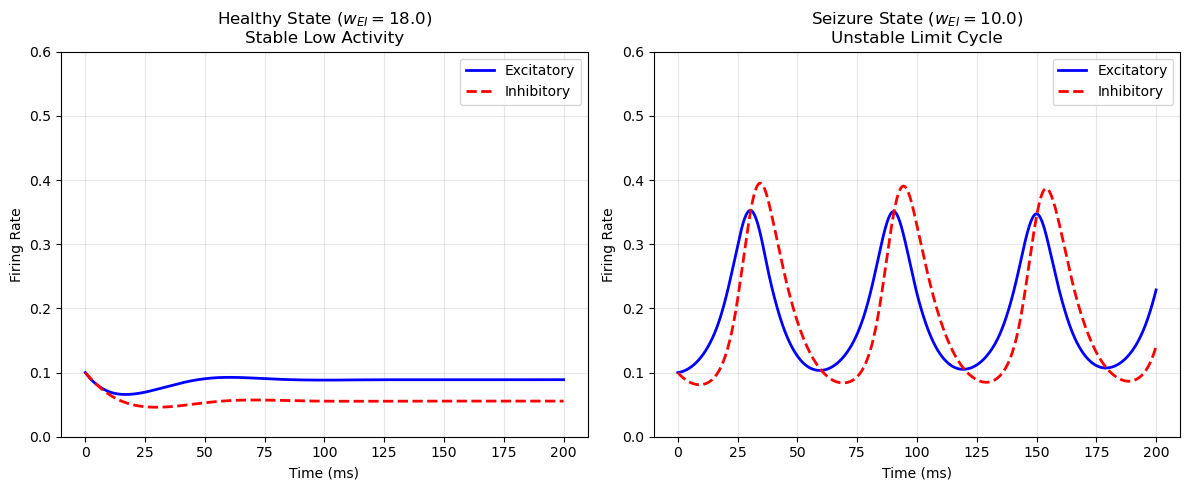

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# 1. PARAMETERS 

params = {
    'tau_E': 10.0,
    'tau_I': 10.0,
    'w_EE': 16.0,     # Strong Self-Excitation (The "Gas")
    'w_II': 3.0,      # Weak Self-Inhibition
    'w_IE': 15.0,     # Strong Excitation -> Inhibition drive
    'input_E': 1.25,  # Moderate external drive (Essential!)
    'input_I': 0.0,
    'a': 1.0,
    'theta': 4.0      # Standard Threshold
}

# --- THE EXPERIMENT ---
# CASE A: HEALTHY (Strong Inhibition)
# strong enough to suppress the input
w_EI_healthy = 18.0 

# CASE B: SEIZURE (Weakened Inhibition)
# The "brakes" are weakened just enough to allow oscillation, 
# but not so weak that the system locks up entirely
w_EI_seizure = 10.0 

# Settings
t_span = (0, 200)
t_eval = np.linspace(0, 200, 5000) 
initial_state = [0.1, 0.1]

# 2. MODEL DEFINITION

def sigmoid(x, a, theta):
    return 1 / (1 + np.exp(-a * (x - theta)))

def wilson_cowan(t, state, p, w_EI_current):
    E, I = state
    # Inputs
    input_to_E = p['w_EE'] * E - w_EI_current * I + p['input_E']
    input_to_I = p['w_IE'] * E - p['w_II'] * I    + p['input_I']
    # Derivatives
    dEdt = (-E + sigmoid(input_to_E, p['a'], p['theta'])) / p['tau_E']
    dIdt = (-I + sigmoid(input_to_I, p['a'], p['theta'])) / p['tau_I']
    return [dEdt, dIdt]


# Run Healthy
sol_healthy = solve_ivp(
    fun=lambda t, y: wilson_cowan(t, y, params, w_EI_healthy),
    t_span=t_span, y0=initial_state, t_eval=t_eval, method='RK45'
)

# Run Seizure
sol_seizure = solve_ivp(
    fun=lambda t, y: wilson_cowan(t, y, params, w_EI_seizure),
    t_span=t_span, y0=initial_state, t_eval=t_eval, method='RK45'
)


plt.figure(figsize=(12, 5))

# Plot Healthy
plt.subplot(1, 2, 1)
plt.plot(sol_healthy.t, sol_healthy.y[0], 'b-', linewidth=2, label='Excitatory')
plt.plot(sol_healthy.t, sol_healthy.y[1], 'r--', linewidth=2, label='Inhibitory')
plt.title(f'Healthy State ($w_{{EI}}={w_EI_healthy}$)\nStable Low Activity')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate')
plt.ylim([0, 0.6])
plt.legend()
plt.grid(True, alpha=0.3)

# Plot Seizure
plt.subplot(1, 2, 2)
plt.plot(sol_seizure.t, sol_seizure.y[0], 'b-', linewidth=2, label='Excitatory')
plt.plot(sol_seizure.t, sol_seizure.y[1], 'r--', linewidth=2, label='Inhibitory')
plt.title(f'Seizure State ($w_{{EI}}={w_EI_seizure}$)\nUnstable Limit Cycle')
plt.xlabel('Time (ms)')
plt.ylabel('Firing Rate')
plt.ylim([0, 0.6])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

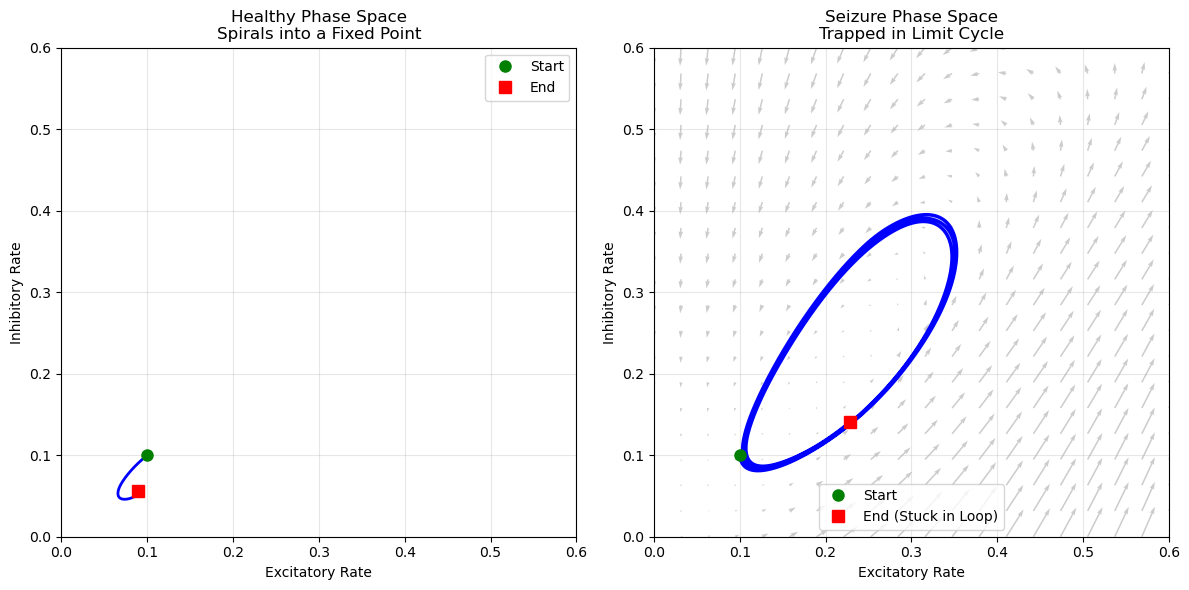

In [ ]:
# Phase Plane Analysis 

plt.figure(figsize=(12, 6))

# HEALTHY TRAJECTORY 
plt.subplot(1, 2, 1)
plt.plot(sol_healthy.y[0], sol_healthy.y[1], 'b-', linewidth=2)
# 
plt.plot(sol_healthy.y[0][0], sol_healthy.y[1][0], 'go', markersize=8, label='Start')
plt.plot(sol_healthy.y[0][-1], sol_healthy.y[1][-1], 'rs', markersize=8, label='End')
plt.title(f'Healthy Phase Space\nSpirals into a Fixed Point')
plt.xlabel('Excitatory Rate')
plt.ylabel('Inhibitory Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([0, 0.6])
plt.ylim([0, 0.6])

# SEIZURE TRAJECTORY 
plt.subplot(1, 2, 2)
# Calculate Vector Field for Seizure
E_grid, I_grid = np.meshgrid(np.linspace(0, 0.6, 20), np.linspace(0, 0.6, 20))
dE, dI = np.zeros(E_grid.shape), np.zeros(I_grid.shape)
for i in range(20):
    for j in range(20):
        # Calculate direction at each point
        rates = wilson_cowan(0, [E_grid[i,j], I_grid[i,j]], params, w_EI_seizure)
        dE[i,j], dI[i,j] = rates[0], rates[1]

# Plot Arrows
plt.quiver(E_grid, I_grid, dE, dI, color='gray', alpha=0.4)

# Plot Trajectory
plt.plot(sol_seizure.y[0], sol_seizure.y[1], 'b-', linewidth=2.5)
plt.plot(sol_seizure.y[0][0], sol_seizure.y[1][0], 'go', markersize=8, label='Start')
plt.plot(sol_seizure.y[0][-1], sol_seizure.y[1][-1], 'rs', markersize=8, label='End (Stuck in Loop)')

plt.title(f'Seizure Phase Space\nTrapped in Limit Cycle')
plt.xlabel('Excitatory Rate')
plt.ylabel('Inhibitory Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim([0, 0.6])
plt.ylim([0, 0.6])

plt.tight_layout()
plt.show()

### At exactly what inhibition level does the brain tip over into a seizure?

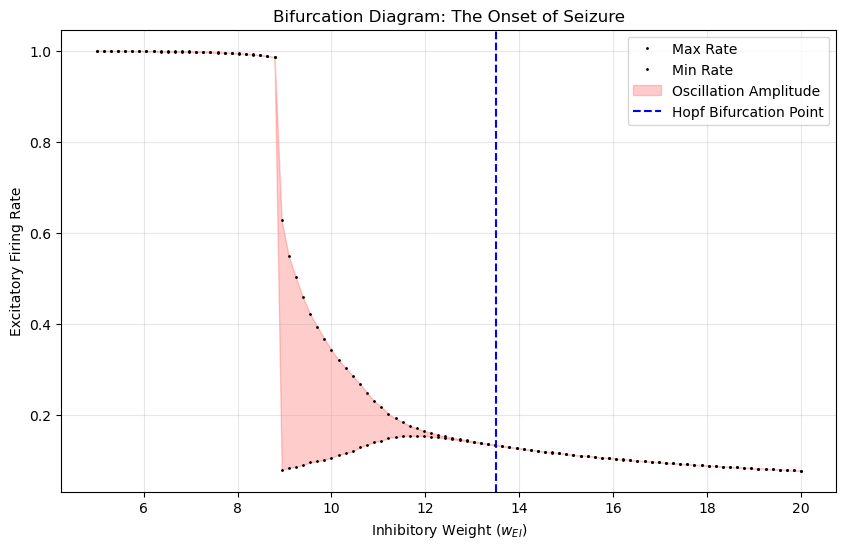

In [ ]:
# Range of inhibition values to test (from Seizure to Healthy)
w_EI_range = np.linspace(5, 20, 100) 
min_E = []
max_E = []

for w in w_EI_range:
    # Run a short simulation for each weight
    sol = solve_ivp(
        fun=lambda t, y: wilson_cowan(t, y, params, w),
        t_span=(0, 300), y0=initial_state, t_eval=np.linspace(0, 300, 1000), method='RK45'
    )
    
    last_idx = int(len(sol.y[0]) * 0.8)
    steady_E = sol.y[0][last_idx:]
    
   
    min_E.append(np.min(steady_E))
    max_E.append(np.max(steady_E))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(w_EI_range, max_E, 'k.', markersize=2, label='Max Rate')
plt.plot(w_EI_range, min_E, 'k.', markersize=2, label='Min Rate')
plt.fill_between(w_EI_range, min_E, max_E, color='red', alpha=0.2, label='Oscillation Amplitude')

plt.title('Bifurcation Diagram: The Onset of Seizure')
plt.xlabel('Inhibitory Weight ($w_{EI}$)')
plt.ylabel('Excitatory Firing Rate')
plt.axvline(x=13.5, color='b', linestyle='--', label='Hopf Bifurcation Point') 
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### The Bifurcation Point (at $w_{EI} \approx 12$)
#### The single line splits open like a mouth. This is the Hopf Bifurcation. This is the exact mathematical tipping point where the "Stable Fixed Point" loses its stability and gives birth to a "Limit Cycle."

#### This represents the onset of the seizure. The inhibition has become just weak enough that it can no longer clamp the excitation immediately.